# Titanic: Best EML Tree vs Tuned CatBoost

This notebook is a compact, reproducible report for the current frontier of the project on the normalized Titanic training set.

What happens below:
- load the prepared `[0, 1]` features from `data/interim/titanic_unit_interval_train.csv`
- compare the current best `EML` tree with three `CatBoost` regimes on the same shared-CV folds
- show how hyperparameter tuning changes `ROC AUC`, `logloss`, and the train/OOF gap
- keep the strongest symbolic model visible as a readable tree diagram

The metric to trust most is `OOF` (`out-of-fold`): every row is scored by a model that did not train on that row.


In [1]:
from __future__ import annotations

import csv
import html
import io
import json
import math
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from catboost import CatBoostClassifier
from IPython.display import HTML, Image as DisplayImage, display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from titanic_mle.catboost_profiles import (
    CATBOOST_BASELINE_PARAMS,
    CATBOOST_BASELINE_PROFILE_ID,
    CATBOOST_TUNED_BALANCED_PARAMS,
    CATBOOST_TUNED_BALANCED_PROFILE_ID,
    CATBOOST_TUNED_BEST_AUC_PARAMS,
    CATBOOST_TUNED_BEST_AUC_PROFILE_ID,
)
from titanic_mle.metrics import binary_logloss, roc_auc_score

TRAIN_PATH = ROOT / 'data' / 'interim' / 'titanic_unit_interval_train.csv'
TREE_REPORT_PATH = ROOT / 'data' / 'processed' / 'ga_meta_stacked_top12__lib12_iter1__auc_calibrated_logloss.json'

SEED = 20_260_420
FOLDS = 5
CATBOOST_PROFILE_LABELS = {
    CATBOOST_BASELINE_PROFILE_ID: 'CatBoost baseline',
    CATBOOST_TUNED_BEST_AUC_PROFILE_ID: 'CatBoost tuned (best OOF AUC)',
    CATBOOST_TUNED_BALANCED_PROFILE_ID: 'CatBoost tuned (balanced)',
}


def load_train_rows() -> tuple[list[dict[str, float]], list[int], list[str]]:
    with TRAIN_PATH.open() as handle:
        reader = csv.DictReader(handle)
        rows = []
        labels = []
        for row in reader:
            parsed = {key: float(value) for key, value in row.items() if key != 'Survived'}
            rows.append(parsed)
            labels.append(int(row['Survived']))
    feature_names = [name for name in rows[0].keys() if name != 'PassengerId']
    return rows, labels, feature_names


rows, labels, feature_names = load_train_rows()

profiles_html = ''.join(
    f"<li><code>{profile_id}</code>: {label}</li>"
    for profile_id, label in CATBOOST_PROFILE_LABELS.items()
)

display(HTML(
    "<div style='display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;margin:6px 0 14px 0;'>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#eff6ff;border:1px solid #bfdbfe;'><div style='font-size:12px;color:#1d4ed8;'>Rows</div><div style='font-size:28px;font-weight:800;color:#0f172a;'>{len(rows)}</div></div>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#ecfdf5;border:1px solid #bbf7d0;'><div style='font-size:12px;color:#15803d;'>Features</div><div style='font-size:28px;font-weight:800;color:#0f172a;'>{len(feature_names)}</div></div>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#fff7ed;border:1px solid #fed7aa;'><div style='font-size:12px;color:#c2410c;'>Folds</div><div style='font-size:28px;font-weight:800;color:#0f172a;'>{FOLDS}</div></div>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#faf5ff;border:1px solid #e9d5ff;'><div style='font-size:12px;color:#7e22ce;'>Seed</div><div style='font-size:28px;font-weight:800;color:#0f172a;'>{SEED}</div></div>"
    "</div>"
    f"<p style='margin:0 0 10px 0;color:#475569;'>Dataset: <code>{TRAIN_PATH.relative_to(ROOT)}</code><br>Best tree report: <code>{TREE_REPORT_PATH.relative_to(ROOT)}</code></p>"
    "<div style='padding:14px 16px;border-radius:18px;background:#f8fafc;border:1px solid #cbd5e1;'>"
    "<div style='font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#475569;margin-bottom:6px;'>CatBoost Profiles In This Notebook</div>"
    f"<ul style='margin:0;padding-left:18px;color:#334155;'>{profiles_html}</ul>"
    "</div>"
))


## Data Snapshot

The project already transformed the Titanic features into the unit interval.

A few examples:
- `sex_unit`: `male -> 0`, `female -> 1`
- `embarked_unit`: `C -> 0`, `Q -> 0.5`, `S -> 1`
- `age_unit`: `clip(age / 80, 0, 1)`

That makes the dataset compatible with the EML grammar while still preserving enough structure for ordinary ML baselines like CatBoost.

In [2]:
positive_rate = sum(labels) / len(labels)
sample_columns = [
    'PassengerId',
    'pclass_unit',
    'sex_unit',
    'age_unit',
    'fare_unit',
    'embarked_unit',
    'family_size_unit',
]
sample_rows = rows[:6]

header_html = ''.join(
    f"<th style='text-align:left;padding:8px 10px;border-bottom:1px solid #cbd5e1;'>{html.escape(column)}</th>"
    for column in sample_columns + ['Survived']
)
body_html = []
for row, label in zip(sample_rows, labels[:6]):
    values = [row[column] for column in sample_columns] + [label]
    rendered = ''.join(
        f"<td style='padding:8px 10px;border-bottom:1px solid #e2e8f0;'>{value:.3f}</td>" if isinstance(value, float) else f"<td style='padding:8px 10px;border-bottom:1px solid #e2e8f0;'>{value}</td>"
        for value in values
    )
    body_html.append(f'<tr>{rendered}</tr>')

feature_preview = ', '.join(feature_names[:8])
profile_preview = ', '.join(CATBOOST_PROFILE_LABELS.values())

display(HTML(
    "<div style='display:grid;grid-template-columns:repeat(3,minmax(160px,1fr));gap:12px;margin:8px 0 16px 0;'>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#f8fafc;border:1px solid #cbd5e1;'><div style='font-size:12px;color:#475569;'>Positive Rate</div><div style='font-size:28px;font-weight:800;color:#0f172a;'>{positive_rate:.3f}</div></div>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#f8fafc;border:1px solid #cbd5e1;'><div style='font-size:12px;color:#475569;'>First Features</div><div style='font-size:15px;font-weight:700;color:#0f172a;'>{html.escape(feature_preview)}</div></div>"
    f"<div style='padding:14px 16px;border-radius:18px;background:#f8fafc;border:1px solid #cbd5e1;'><div style='font-size:12px;color:#475569;'>Compared Profiles</div><div style='font-size:15px;font-weight:700;color:#0f172a;'>{html.escape(profile_preview)}</div></div>"
    "</div>"
    "<div style='overflow-x:auto;'>"
    "<table style='border-collapse:collapse;width:100%;font-size:13px;background:white;border:1px solid #e2e8f0;border-radius:14px;overflow:hidden;'>"
    f"<thead style='background:#f8fafc;'><tr>{header_html}</tr></thead>"
    f"<tbody>{''.join(body_html)}</tbody>"
    "</table>"
    "</div>"
))


PassengerId,pclass_unit,sex_unit,age_unit,fare_unit,embarked_unit,family_size_unit,Survived
1.000,0.000,0.000,0.275,0.014,1.000,0.182,0
2.000,1.000,1.000,0.475,0.139,0.000,0.182,1
3.000,0.000,1.000,0.325,0.015,1.000,0.091,1
4.000,1.000,1.000,0.438,0.104,1.000,0.182,1
5.000,0.000,0.000,0.438,0.016,1.000,0.091,0
6.000,0.000,0.000,0.350,0.017,0.500,0.091,0


## Shared-CV Benchmark Protocol

All model comparisons below use the same stratified 5-fold split.

- `EML tree`: a fixed symbolic expression loaded from the saved top-12 frontier report.
- `CatBoost baseline`: the old depth-6 profile that fit the train set too aggressively.
- `CatBoost tuned (best OOF AUC)`: the strongest shared-CV CatBoost candidate from the tuning sweep.
- `CatBoost tuned (balanced)`: a more conservative profile with a smaller train/OOF gap.

This is still not a nested-search notebook, but it is a fair same-fold benchmark between the current symbolic model and several CatBoost regimes.


In [3]:
@dataclass(frozen=True)
class TerminalSpec:
    terminal_id: str
    feature_a: str
    feature_b: str
    pair_expr: str
    calibration_scale: float
    calibration_bias: float


@dataclass(frozen=True)
class EmlModelSpec:
    model_name: str
    meta_expr: str
    terminals: list[TerminalSpec]


@dataclass(frozen=True)
class CvResult:
    model_name: str
    train_auc: float
    train_logloss: float
    oof_auc: float
    oof_logloss: float
    mean_fold_auc: float
    fold_aucs: list[float]


def stratified_folds(targets: list[int], n_folds: int, seed: int) -> list[list[int]]:
    positives = [index for index, label in enumerate(targets) if label == 1]
    negatives = [index for index, label in enumerate(targets) if label == 0]
    rng = random.Random(seed)
    rng.shuffle(positives)
    rng.shuffle(negatives)
    folds = [[] for _ in range(n_folds)]
    for indices in (positives, negatives):
        for offset, index in enumerate(indices):
            folds[offset % n_folds].append(index)
    for fold in folds:
        fold.sort()
    return folds


def sigmoid(value: float) -> float:
    if value >= 0:
        exp_term = math.exp(-value)
        return 1.0 / (1.0 + exp_term)
    exp_term = math.exp(value)
    return exp_term / (1.0 + exp_term)


def affine_logloss(scores: list[float], targets: list[int], scale: float, bias: float) -> float:
    probabilities = [min(max(sigmoid(scale * score + bias), 1e-15), 1 - 1e-15) for score in scores]
    return binary_logloss(targets, probabilities)


def fit_sigmoid_affine(scores: list[float], targets: list[int]) -> tuple[float, float]:
    scale = 1.0
    bias = 0.0
    best_loss = affine_logloss(scores, targets, scale, bias)
    for _ in range(25):
        g_scale = 0.0
        g_bias = 0.0
        h_ss = 0.0
        h_sb = 0.0
        h_bb = 0.0
        for score, label in zip(scores, targets):
            probability = sigmoid(scale * score + bias)
            error = probability - float(label)
            variance = probability * (1.0 - probability)
            g_scale += error * score
            g_bias += error
            h_ss += variance * score * score
            h_sb += variance * score
            h_bb += variance
        determinant = h_ss * h_bb - h_sb * h_sb
        if determinant <= 1e-18:
            break
        step_scale = (h_bb * g_scale - h_sb * g_bias) / determinant
        step_bias = (-h_sb * g_scale + h_ss * g_bias) / determinant
        step_factor = 1.0
        improved = None
        while step_factor > 1e-8:
            candidate_scale = scale - step_factor * step_scale
            candidate_bias = bias - step_factor * step_bias
            if candidate_scale <= 1e-10:
                step_factor *= 0.5
                continue
            candidate_loss = affine_logloss(scores, targets, candidate_scale, candidate_bias)
            if candidate_loss < best_loss - 1e-12:
                improved = (candidate_scale, candidate_bias, candidate_loss)
                break
            step_factor *= 0.5
        if improved is None:
            break
        scale, bias, best_loss = improved
        if abs(step_factor * step_scale) < 1e-10 and abs(step_factor * step_bias) < 1e-10:
            break
    return scale, bias


def apply_sigmoid_affine(scores: list[float], scale: float, bias: float) -> list[float]:
    return [min(max(sigmoid(scale * score + bias), 1e-15), 1 - 1e-15) for score in scores]


class PairExpr:
    def __init__(self, kind: str, left: 'PairExpr | None' = None, right: 'PairExpr | None' = None):
        self.kind = kind
        self.left = left
        self.right = right

    def eval(self, x0: float, x1: float) -> float:
        if self.kind == '1':
            return 1.0
        if self.kind == 'x0':
            return x0
        if self.kind == 'x1':
            return x1
        left_value = self.left.eval(x0, x1)
        right_value = self.right.eval(x0, x1)
        if right_value <= 0.0:
            raise ValueError('log domain')
        value = math.exp(left_value) - math.log(right_value)
        if not math.isfinite(value):
            raise ValueError('non-finite')
        return value


class MetaExpr:
    def __init__(self, kind: str, left: 'MetaExpr | None' = None, right: 'MetaExpr | None' = None):
        self.kind = kind
        self.left = left
        self.right = right

    def eval(self, terminals: dict[str, float]) -> float:
        if self.kind != 'node':
            return terminals[self.kind]
        left_value = self.left.eval(terminals)
        right_value = self.right.eval(terminals)
        if right_value <= 0.0:
            raise ValueError('log domain')
        value = math.exp(left_value) - math.log(right_value)
        if not math.isfinite(value):
            raise ValueError('non-finite')
        return value


def parse_pair_expr(text: str) -> PairExpr:
    index = 0

    def skip_ws() -> None:
        nonlocal index
        while index < len(text) and text[index].isspace():
            index += 1

    def parse() -> PairExpr:
        nonlocal index
        skip_ws()
        if text.startswith('x0', index):
            index += 2
            return PairExpr('x0')
        if text.startswith('x1', index):
            index += 2
            return PairExpr('x1')
        if text[index] == '1':
            index += 1
            return PairExpr('1')
        if text[index] != '(':
            raise ValueError(f'unexpected token: {text[index:]}')
        index += 1
        left = parse()
        right = parse()
        skip_ws()
        if text[index] != ')':
            raise ValueError('missing closing )')
        index += 1
        return PairExpr('node', left, right)

    expr = parse()
    skip_ws()
    if index != len(text):
        raise ValueError('trailing input')
    return expr


def tokenize_meta(text: str) -> list[str]:
    tokens: list[str] = []
    current: list[str] = []
    for ch in text:
        if ch in '()':
            if current:
                tokens.append(''.join(current))
                current.clear()
            tokens.append(ch)
        elif ch.isspace():
            if current:
                tokens.append(''.join(current))
                current.clear()
        else:
            current.append(ch)
    if current:
        tokens.append(''.join(current))
    return tokens


def parse_meta_expr(text: str) -> MetaExpr:
    tokens = tokenize_meta(text)
    index = 0

    def parse() -> MetaExpr:
        nonlocal index
        token = tokens[index]
        if token == '(':
            index += 1
            left = parse()
            right = parse()
            if tokens[index] != ')':
                raise ValueError('missing closing )')
            index += 1
            return MetaExpr('node', left, right)
        index += 1
        return MetaExpr(token)

    expr = parse()
    if index != len(tokens):
        raise ValueError('trailing input')
    return expr


def load_eml_model(report_path: Path, model_name: str) -> EmlModelSpec:
    report = json.loads(report_path.read_text())
    terminals = [
        TerminalSpec(
            terminal_id=row['id'],
            feature_a=row['feature_a'],
            feature_b=row['feature_b'],
            pair_expr=row['source_expression'],
            calibration_scale=row['fitted_calibration_scale'],
            calibration_bias=row['fitted_calibration_bias'],
        )
        for row in report['terminals']
    ]
    return EmlModelSpec(model_name=model_name, meta_expr=report['best_expression'], terminals=terminals)


def benchmark_eml_model(spec: EmlModelSpec, rows: list[dict[str, float]], targets: list[int], folds: list[list[int]]) -> CvResult:
    pair_exprs = {terminal.terminal_id: parse_pair_expr(terminal.pair_expr) for terminal in spec.terminals}
    meta_expr = parse_meta_expr(spec.meta_expr)
    raw_terminal_scores = {
        terminal.terminal_id: [
            pair_exprs[terminal.terminal_id].eval(row[terminal.feature_a], row[terminal.feature_b])
            for row in rows
        ]
        for terminal in spec.terminals
    }
    terminal_probabilities = {
        terminal.terminal_id: apply_sigmoid_affine(
            raw_terminal_scores[terminal.terminal_id],
            terminal.calibration_scale,
            terminal.calibration_bias,
        )
        for terminal in spec.terminals
    }
    meta_scores = [
        meta_expr.eval({terminal_id: values[row_index] for terminal_id, values in terminal_probabilities.items()})
        for row_index in range(len(rows))
    ]
    full_scale, full_bias = fit_sigmoid_affine(meta_scores, targets)
    train_probabilities = apply_sigmoid_affine(meta_scores, full_scale, full_bias)
    train_auc = roc_auc_score(targets, train_probabilities)
    train_logloss = binary_logloss(targets, train_probabilities)

    oof_probabilities = [0.0] * len(rows)
    fold_aucs: list[float] = []
    for fold_indices in folds:
        validation_set = set(fold_indices)
        train_indices = [index for index in range(len(rows)) if index not in validation_set]
        train_scores = [meta_scores[index] for index in train_indices]
        train_targets = [targets[index] for index in train_indices]
        valid_scores = [meta_scores[index] for index in fold_indices]
        valid_targets = [targets[index] for index in fold_indices]
        fold_scale, fold_bias = fit_sigmoid_affine(train_scores, train_targets)
        valid_probabilities = apply_sigmoid_affine(valid_scores, fold_scale, fold_bias)
        for index, probability in zip(fold_indices, valid_probabilities):
            oof_probabilities[index] = probability
        fold_aucs.append(roc_auc_score(valid_targets, valid_probabilities))

    return CvResult(
        model_name=spec.model_name,
        train_auc=train_auc,
        train_logloss=train_logloss,
        oof_auc=roc_auc_score(targets, oof_probabilities),
        oof_logloss=binary_logloss(targets, oof_probabilities),
        mean_fold_auc=sum(fold_aucs) / len(fold_aucs),
        fold_aucs=fold_aucs,
    )


def build_matrix(rows: list[dict[str, float]], used_features: list[str]) -> list[list[float]]:
    return [[row[name] for name in used_features] for row in rows]


def fit_catboost(x_train: list[list[float]], y_train: list[int], x_eval: list[list[float]], params: dict[str, object]) -> list[float]:
    model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
        **params,
    )
    model.fit(x_train, y_train)
    return [float(probability) for probability in model.predict_proba(x_eval)[:, 1]]


def benchmark_catboost_model(
    model_name: str,
    used_features: list[str],
    rows: list[dict[str, float]],
    targets: list[int],
    folds: list[list[int]],
    params: dict[str, object],
) -> CvResult:
    matrix = build_matrix(rows, used_features)
    train_probabilities = fit_catboost(matrix, targets, matrix, params)
    train_auc = roc_auc_score(targets, train_probabilities)
    train_logloss = binary_logloss(targets, train_probabilities)

    oof_probabilities = [0.0] * len(rows)
    fold_aucs: list[float] = []
    for fold_indices in folds:
        validation_set = set(fold_indices)
        train_x = [row for index, row in enumerate(matrix) if index not in validation_set]
        train_y = [label for index, label in enumerate(targets) if index not in validation_set]
        valid_x = [matrix[index] for index in fold_indices]
        valid_y = [targets[index] for index in fold_indices]
        valid_probabilities = fit_catboost(train_x, train_y, valid_x, params)
        for index, probability in zip(fold_indices, valid_probabilities):
            oof_probabilities[index] = probability
        fold_aucs.append(roc_auc_score(valid_y, valid_probabilities))

    return CvResult(
        model_name=model_name,
        train_auc=train_auc,
        train_logloss=train_logloss,
        oof_auc=roc_auc_score(targets, oof_probabilities),
        oof_logloss=binary_logloss(targets, oof_probabilities),
        mean_fold_auc=sum(fold_aucs) / len(fold_aucs),
        fold_aucs=fold_aucs,
    )


Model,Train ROC AUC,OOF ROC AUC,AUC Gap,Train Logloss,OOF Logloss,Logloss Gap
best_eml_tree,0.871918,0.869252,0.002666,0.443408,0.444346,0.000938
CatBoost baseline,0.984065,0.860427,0.123638,0.192931,0.447891,0.254959
CatBoost tuned (best OOF AUC),0.910523,0.870378,0.040145,0.357878,0.414767,0.056890
CatBoost tuned (balanced),0.903314,0.869052,0.034262,0.370875,0.416813,0.045938


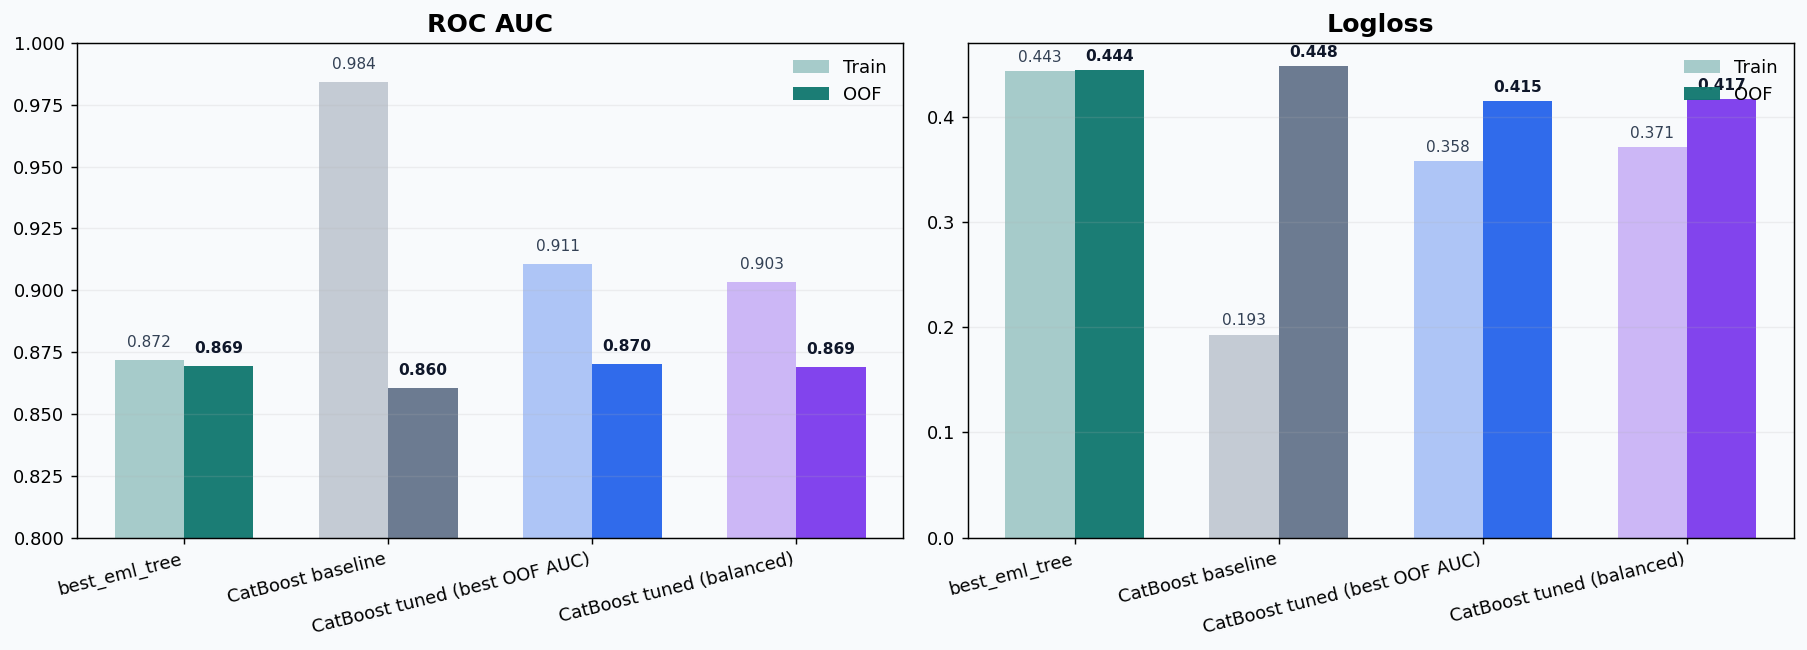

In [4]:
folds = stratified_folds(labels, FOLDS, SEED)

best_tree_spec = load_eml_model(TREE_REPORT_PATH, 'best_eml_tree')
best_tree_result = benchmark_eml_model(best_tree_spec, rows, labels, folds)
catboost_baseline_result = benchmark_catboost_model('CatBoost baseline', feature_names, rows, labels, folds, CATBOOST_BASELINE_PARAMS)
catboost_tuned_auc_result = benchmark_catboost_model('CatBoost tuned (best OOF AUC)', feature_names, rows, labels, folds, CATBOOST_TUNED_BEST_AUC_PARAMS)
catboost_tuned_balanced_result = benchmark_catboost_model('CatBoost tuned (balanced)', feature_names, rows, labels, folds, CATBOOST_TUNED_BALANCED_PARAMS)

benchmark_results = {
    'best_eml_tree': best_tree_result,
    'catboost_baseline': catboost_baseline_result,
    'catboost_tuned_auc': catboost_tuned_auc_result,
    'catboost_tuned_balanced': catboost_tuned_balanced_result,
}

ordered_results = [
    best_tree_result,
    catboost_baseline_result,
    catboost_tuned_auc_result,
    catboost_tuned_balanced_result,
]

auc_leader = max(ordered_results, key=lambda result: result.oof_auc)
logloss_leader = min(ordered_results, key=lambda result: result.oof_logloss)
lowest_gap_model = min(ordered_results, key=lambda result: result.train_auc - result.oof_auc)

baseline_auc_gap = catboost_baseline_result.train_auc - catboost_baseline_result.oof_auc
tuned_auc_gap = catboost_tuned_auc_result.train_auc - catboost_tuned_auc_result.oof_auc
gap_reduction = 1.0 - tuned_auc_gap / baseline_auc_gap

tree_auc_delta = best_tree_result.oof_auc - catboost_tuned_auc_result.oof_auc
tree_logloss_delta = best_tree_result.oof_logloss - catboost_tuned_auc_result.oof_logloss
if tree_auc_delta >= 0:
    tree_vs_catboost_text = (
        f"The current EML tree still leads the strongest tuned CatBoost on OOF AUC by {tree_auc_delta:.6f}, "
        f"but its OOF logloss is higher by {tree_logloss_delta:.6f}."
    )
else:
    tree_vs_catboost_text = (
        f"The strongest tuned CatBoost now leads the current EML tree by {abs(tree_auc_delta):.6f} OOF AUC "
        f"and by {tree_logloss_delta:.6f} lower OOF logloss."
    )

rows_html = []
for row in ordered_results:
    auc_gap = row.train_auc - row.oof_auc
    logloss_gap = row.oof_logloss - row.train_logloss
    rows_html.append(
        '<tr>'
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;font-weight:700;'>{row.model_name}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{row.train_auc:.6f}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{row.oof_auc:.6f}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{auc_gap:.6f}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{row.train_logloss:.6f}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{row.oof_logloss:.6f}</td>"
        f"<td style='padding:10px 12px;border-bottom:1px solid #e2e8f0;'>{logloss_gap:.6f}</td>"
        '</tr>'
    )

summary_html = (
    "<div style='padding:16px 18px;border-radius:20px;background:linear-gradient(135deg,#f8fafc,#eef2ff);border:1px solid #cbd5e1;margin:10px 0 18px 0;'>"
    "<div style='font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#475569;margin-bottom:6px;'>Shared-CV Verdict</div>"
    f"<div style='font-size:24px;font-weight:800;color:#0f172a;margin-bottom:8px;'>OOF AUC leader: {auc_leader.model_name} | OOF logloss leader: {logloss_leader.model_name}</div>"
    f"<div style='color:#334155;margin-bottom:6px;'>Tuning cut the CatBoost ROC AUC gap from <strong>{baseline_auc_gap:.6f}</strong> to <strong>{tuned_auc_gap:.6f}</strong>, a relative reduction of <strong>{gap_reduction:.1%}</strong>.</div>"
    f"<div style='color:#334155;margin-bottom:6px;'>The most conservative strong model by train/OOF AUC gap is <strong>{lowest_gap_model.model_name}</strong>.</div>"
    f"<div style='color:#334155;'>{tree_vs_catboost_text}</div>"
    "</div>"
)

display(HTML(
    summary_html
    + "<div style='overflow-x:auto;'>"
    + "<table style='border-collapse:collapse;width:100%;font-size:14px;background:white;border:1px solid #e2e8f0;border-radius:16px;overflow:hidden;'>"
    + "<thead style='background:#f8fafc;'><tr>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>Model</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>Train ROC AUC</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>OOF ROC AUC</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>AUC Gap</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>Train Logloss</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>OOF Logloss</th>"
    + "<th style='text-align:left;padding:10px 12px;border-bottom:1px solid #cbd5e1;'>Logloss Gap</th>"
    + "</tr></thead>"
    + f"<tbody>{''.join(rows_html)}</tbody>"
    + "</table></div>"
))

models = [result.model_name for result in ordered_results]
train_auc_values = [result.train_auc for result in ordered_results]
oof_auc_values = [result.oof_auc for result in ordered_results]
train_logloss_values = [result.train_logloss for result in ordered_results]
oof_logloss_values = [result.oof_logloss for result in ordered_results]
colors = ['#0f766e', '#64748b', '#2563eb', '#7c3aed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.1), dpi=130)
fig.patch.set_facecolor('#f8fafc')
for ax in axes:
    ax.set_facecolor('#f8fafc')

x = range(len(models))
bar_width = 0.34

axes[0].bar([i - bar_width / 2 for i in x], train_auc_values, width=bar_width, color=colors, alpha=0.35, label='Train')
axes[0].bar([i + bar_width / 2 for i in x], oof_auc_values, width=bar_width, color=colors, alpha=0.95, label='OOF')
axes[0].set_title('ROC AUC', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(x), models, rotation=14, ha='right')
axes[0].set_ylim(0.80, 1.00)
axes[0].grid(axis='y', alpha=0.18)
axes[0].legend(frameon=False)

axes[1].bar([i - bar_width / 2 for i in x], train_logloss_values, width=bar_width, color=colors, alpha=0.35, label='Train')
axes[1].bar([i + bar_width / 2 for i in x], oof_logloss_values, width=bar_width, color=colors, alpha=0.95, label='OOF')
axes[1].set_title('Logloss', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(x), models, rotation=14, ha='right')
axes[1].grid(axis='y', alpha=0.18)
axes[1].legend(frameon=False)

for ax, values_left, values_right, offset in (
    (axes[0], train_auc_values, oof_auc_values, 0.004),
    (axes[1], train_logloss_values, oof_logloss_values, 0.006),
):
    for index, value in enumerate(values_left):
        ax.text(index - bar_width / 2, value + offset, f'{value:.3f}', ha='center', va='bottom', fontsize=8.5, color='#334155')
    for index, value in enumerate(values_right):
        ax.text(index + bar_width / 2, value + offset, f'{value:.3f}', ha='center', va='bottom', fontsize=8.5, color='#0f172a', fontweight='bold')

plt.tight_layout()
plt.show()


## Best EML Tree

The diagram below is the exact symbolic model used in the benchmark above.

Reading guide:
- dark nodes are `EML(left, right) = exp(left) - ln(right)`
- blue leaves are the strong `pclass × sex` anchors
- green leaves are `sex`-driven terminals
- sand leaves are `pclass`-driven terminals added by the shared-CV terminal expansion

This is the model that currently beats the CatBoost baseline on our shared-CV `OOF ROC AUC` and `OOF logloss` benchmark.

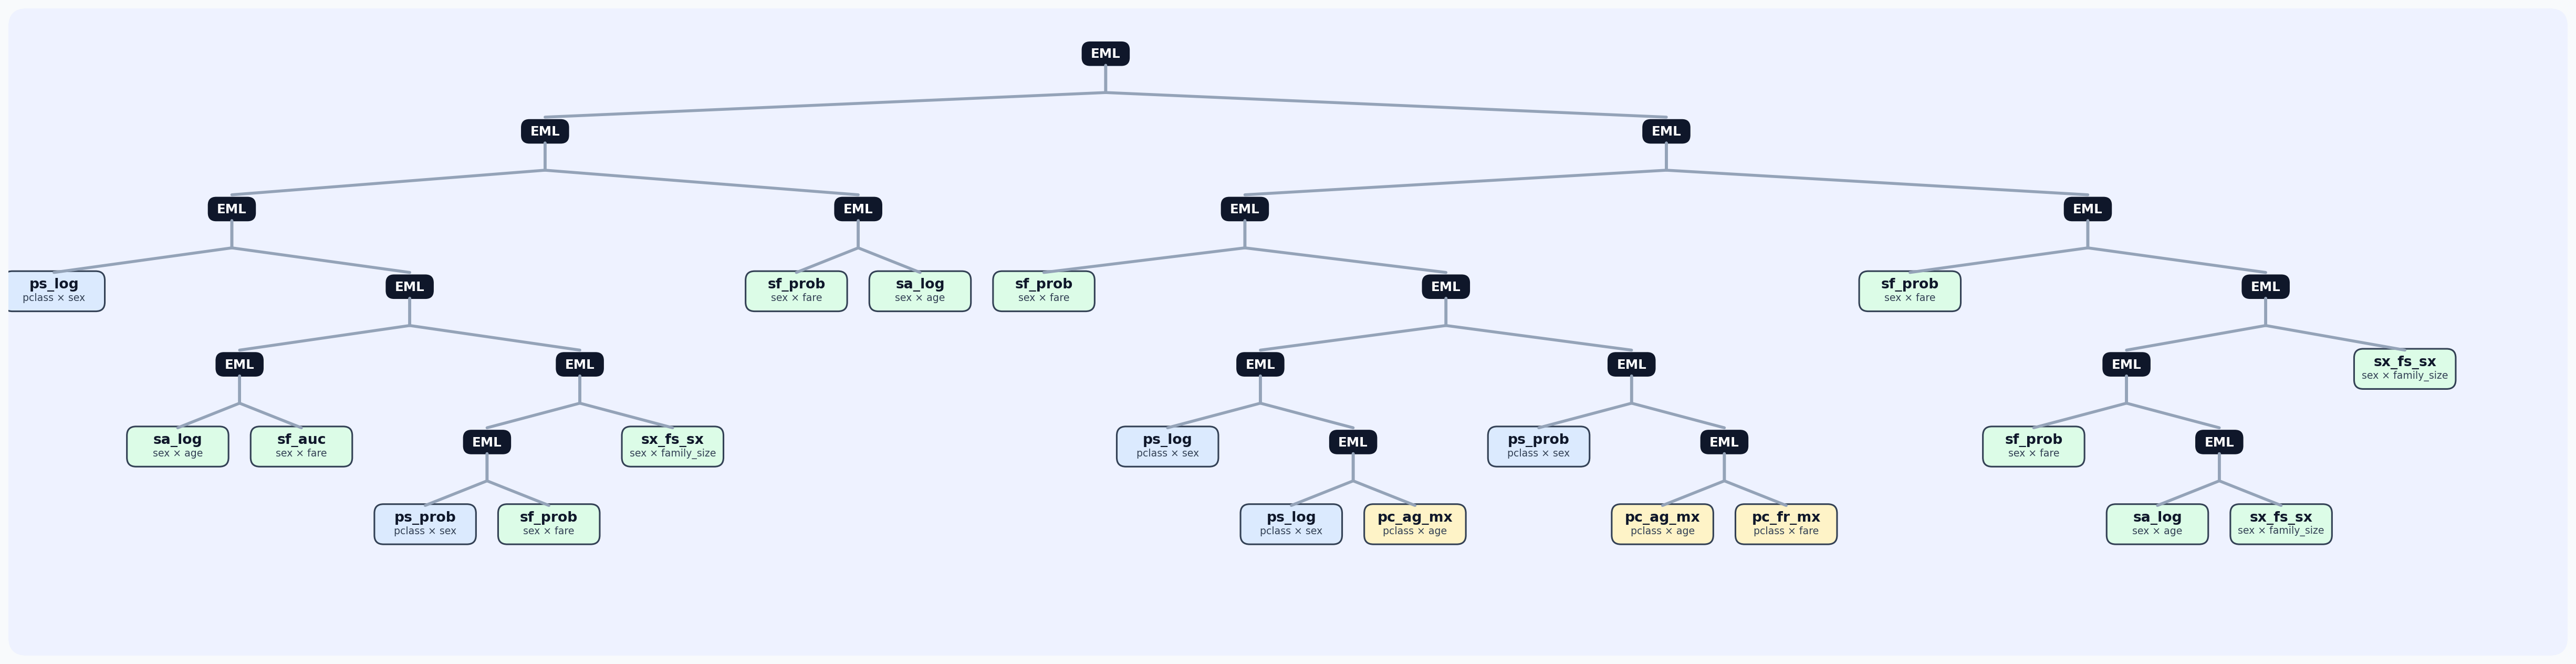

In [5]:
report = json.loads(TREE_REPORT_PATH.read_text())
metrics = benchmark_results['best_eml_tree']
terminals = {row['id']: row for row in report['terminals']}
expr_text = report['best_expression']


def short_feature(name: str) -> str:
    mapping = {
        'pclass_unit': 'pclass',
        'sex_unit': 'sex',
        'age_unit': 'age',
        'age_missing': 'age_missing',
        'sibsp_unit': 'sibsp',
        'parch_unit': 'parch',
        'fare_unit': 'fare',
        'fare_missing': 'fare_missing',
        'embarked_unit': 'embarked',
        'embarked_missing': 'embarked_missing',
        'cabin_known': 'cabin',
        'family_size_unit': 'family_size',
        'is_alone': 'is_alone',
    }
    return mapping.get(name, name)


def leaf_color(term_id: str) -> str:
    term = terminals[term_id]
    pair = {term['feature_a'], term['feature_b']}
    if 'sex_unit' in pair and 'pclass_unit' in pair:
        return '#dbeafe'
    if 'sex_unit' in pair:
        return '#dcfce7'
    if 'pclass_unit' in pair:
        return '#fef3c7'
    return '#f3f4f6'


@dataclass
class Node:
    label: str
    left: 'Node | None' = None
    right: 'Node | None' = None
    depth: int = 0
    x: float = 0.0
    y: float = 0.0

    @property
    def is_leaf(self) -> bool:
        return self.left is None and self.right is None


def tokenize(text: str) -> list[str]:
    tokens: list[str] = []
    current: list[str] = []
    for ch in text:
        if ch in '()':
            if current:
                tokens.append(''.join(current))
                current.clear()
            tokens.append(ch)
        elif ch.isspace():
            if current:
                tokens.append(''.join(current))
                current.clear()
        else:
            current.append(ch)
    if current:
        tokens.append(''.join(current))
    return tokens


def parse_expr(tokens: list[str], index: int = 0) -> tuple[Node, int]:
    token = tokens[index]
    if token == '(':
        left, index = parse_expr(tokens, index + 1)
        right, index = parse_expr(tokens, index)
        if tokens[index] != ')':
            raise ValueError('missing closing parenthesis')
        return Node('EML', left, right), index + 1
    return Node(token), index + 1


def assign_layout(node: Node, depth: int = 0, cursor: list[int] | None = None) -> None:
    if cursor is None:
        cursor = [0]
    node.depth = depth
    if node.is_leaf:
        node.x = cursor[0]
        cursor[0] += 1
    else:
        assign_layout(node.left, depth + 1, cursor)
        assign_layout(node.right, depth + 1, cursor)
        node.x = (node.left.x + node.right.x) / 2
    node.y = depth


def walk(node: Node):
    yield node
    if not node.is_leaf:
        yield from walk(node.left)
        yield from walk(node.right)


tokens = tokenize(expr_text)
root, final_index = parse_expr(tokens)
if final_index != len(tokens):
    raise ValueError('trailing tokens in expression')
assign_layout(root)
nodes = list(walk(root))
max_depth = max(node.depth for node in nodes)
max_x = max(node.x for node in nodes)

leaf_gap = 190
level_gap = 120
padding_x = 70
padding_y = 70
width = int(padding_x * 2 + max_x * leaf_gap + 180)
height = int(padding_y * 2 + max_depth * level_gap + 140)


def px(node: Node) -> float:
    return padding_x + node.x * leaf_gap


def py(node: Node) -> float:
    return padding_y + node.y * level_gap


display(HTML(
    "<div style='display:grid;grid-template-columns:repeat(4,minmax(130px,1fr));gap:12px;margin:8px 0 18px 0;'>"
    f"<div style='padding:12px 14px;border-radius:16px;background:#eff6ff;border:1px solid #bfdbfe;'><div style='font-size:12px;color:#1d4ed8;'>OOF ROC AUC</div><div style='font-size:24px;font-weight:800;color:#0f172a;'>{metrics.oof_auc:.6f}</div></div>"
    f"<div style='padding:12px 14px;border-radius:16px;background:#ecfdf5;border:1px solid #bbf7d0;'><div style='font-size:12px;color:#15803d;'>OOF Logloss</div><div style='font-size:24px;font-weight:800;color:#0f172a;'>{metrics.oof_logloss:.6f}</div></div>"
    f"<div style='padding:12px 14px;border-radius:16px;background:#fff7ed;border:1px solid #fed7aa;'><div style='font-size:12px;color:#c2410c;'>Train ROC AUC</div><div style='font-size:24px;font-weight:800;color:#0f172a;'>{metrics.train_auc:.6f}</div></div>"
    f"<div style='padding:12px 14px;border-radius:16px;background:#faf5ff;border:1px solid #e9d5ff;'><div style='font-size:12px;color:#7e22ce;'>Train Logloss</div><div style='font-size:24px;font-weight:800;color:#0f172a;'>{metrics.train_logloss:.6f}</div></div>"
    "</div>"
))

fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')
ax.set_xlim(0, width)
ax.set_ylim(height, 0)
ax.axis('off')

bg = FancyBboxPatch((0, 0), width, height, boxstyle='round,pad=0.02,rounding_size=28', facecolor='#eef2ff', edgecolor='none')
ax.add_patch(bg)

for node in nodes:
    if node.is_leaf:
        continue
    for child in (node.left, node.right):
        ax.plot([px(node), px(node), px(child)], [py(node) + 18, (py(node) + py(child)) / 2, py(child) - 22], color='#94a3b8', linewidth=2.5, solid_capstyle='round')

for node in nodes:
    x = px(node)
    y = py(node)
    if node.is_leaf:
        term = terminals[node.label]
        rect = FancyBboxPatch((x - 78, y - 24), 156, 62, boxstyle='round,pad=0.02,rounding_size=14', facecolor=leaf_color(node.label), edgecolor='#334155', linewidth=1.4)
        ax.add_patch(rect)
        ax.text(x, y - 3, node.label, ha='center', va='center', fontsize=12, fontweight='bold', color='#0f172a')
        ax.text(x, y + 18, f"{short_feature(term['feature_a'])} × {short_feature(term['feature_b'])}", ha='center', va='center', fontsize=8.5, color='#334155')
    else:
        rect = FancyBboxPatch((x - 36, y - 18), 72, 36, boxstyle='round,pad=0.02,rounding_size=12', facecolor='#0f172a', edgecolor='#0f172a', linewidth=1.0)
        ax.add_patch(rect)
        ax.text(x, y + 1, 'EML', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=160, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close(fig)
display(DisplayImage(data=buf.getvalue()))

display(HTML(
    f"<details style='margin-top:8px;'><summary style='cursor:pointer;font-weight:600;'>Raw stacked expression</summary><pre style='white-space:pre-wrap;word-break:break-word;background:#0f172a;color:#e2e8f0;padding:14px;border-radius:14px;'>{html.escape(expr_text)}</pre></details>"
))
